# §1 - Calling FMAC_data_transform on FMAC data 
(sourced from https://www.kaggle.com/datasets/nikunjhemani/freddie-macs-dataset-pre-processed)

In [1]:
import importlib
import pandas as pd
from FNBAutils import FMAC_data_transformation as fdt

importlib.reload(fdt)

df = pd.read_csv("data/Freddie_Mac.csv")
df.head()

ImportError: cannot import name 'FMAC_data_transformation' from 'FNBAutils' (unknown location)

# §2 - Calling survival_curve_util on month grain data

In [8]:
import importlib
import pandas as pd
from FNBAutils import survival_curve_util as sch

importlib.reload(sch)

df = pd.read_csv("data/FMAC_loan_level_grain.csv")
df.head()

,duration_months,event_observed,is_15yr,orig_year,high_ltv,rate_spread,PropertyState_West Coast,PropertyState_South,PropertyState_Others,PropertyState_Northeast,...,PPM,OrigInterestRate,LTV,OrigUPB,DTI,OCLTV,Units,MIP,FirstTimeHomebuyer,CreditScore
0,52,0,0,1999,1,-0.125,0,0,0,0,...,0,6.750,89.0,117000,27.0,89,1,25,0,670.533671
1,144,0,0,1999,0,-0.375,0,0,1,0,...,0,6.500,73.0,109000,17.0,73,1,0,0,670.533671
2,67,0,0,1999,0,0.000,0,0,1,0,...,0,6.875,75.0,88000,16.0,75,1,0,0,670.533671
3,35,0,0,1999,0,0.000,1,0,0,0,...,0,6.875,76.0,160000,14.0,76,1,0,0,670.533671
4,54,0,0,1999,0,0.250,0,0,0,1,...,0,7.125,78.0,109000,18.0,78,1,0,0,670.533671


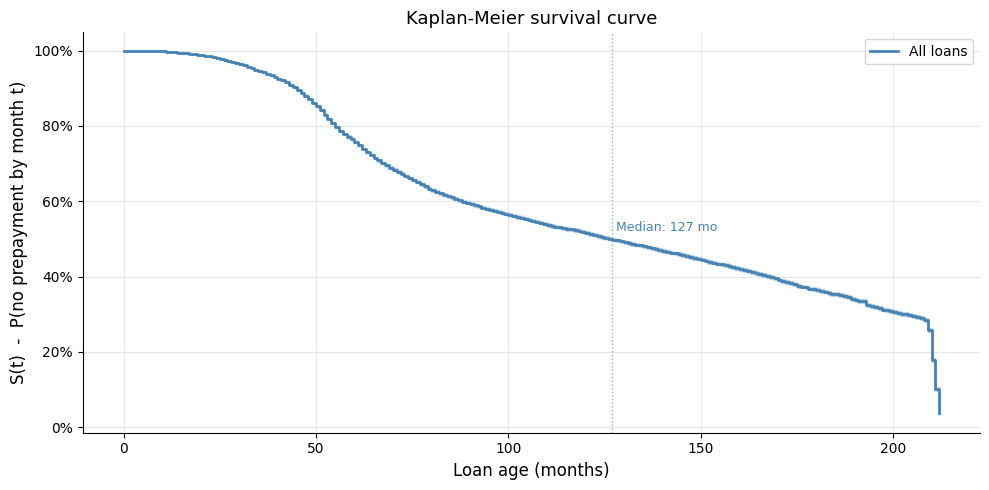

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Kaplan-Meier survival curve'}, xlabel='Loan age (months)', ylabel='S(t)  -  P(no prepayment by month t)'>,
 <lifelines.KaplanMeierFitter:"All loans", fitted with 148938 total observations, 107052 right-censored observations>)

In [9]:
sch.plot_survival_curve(df["duration_months"], df["event_observed"])

In [10]:
results = sch.summary(df["duration_months"], df["event_observed"])
# Visualization shorthand
results

{'total_loans': 148938,
 'events': 41886,
 'event_rate': 0.2812311163034283,
 'censored': 107052,
 'censored_rate': 0.7187688836965718,
 'median_survival_months': 127.0,
 's_at_12mo': 0.9963042446321008,
 's_at_60mo': 0.75701706046948,
 's_at_120mo': 0.51649519801859}

# §3 - Calling cumulative_hazard_util on month grain data

In [4]:
from FNBAutils import hazard_util as chh

importlib.reload(chh)

df = pd.read_csv("data/FMAC_month_level_grain.csv")
df.head()

,duration_months,event_observed,is_15yr,orig_year,high_ltv,rate_spread,PropertyState_West Coast,PropertyState_South,PropertyState_Others,PropertyState_Northeast,...,LTV,OrigUPB,DTI,OCLTV,Units,MIP,FirstTimeHomebuyer,CreditScore,t,event_this_month
0,52.0,0.0,0.0,1999.0,1.0,-0.125,0.0,0.0,0.0,0.0,...,89.0,117000.0,27.0,89.0,1.0,25.0,0.0,670.533671,1.0,0.0
1,52.0,0.0,0.0,1999.0,1.0,-0.125,0.0,0.0,0.0,0.0,...,89.0,117000.0,27.0,89.0,1.0,25.0,0.0,670.533671,2.0,0.0
2,52.0,0.0,0.0,1999.0,1.0,-0.125,0.0,0.0,0.0,0.0,...,89.0,117000.0,27.0,89.0,1.0,25.0,0.0,670.533671,3.0,0.0
3,52.0,0.0,0.0,1999.0,1.0,-0.125,0.0,0.0,0.0,0.0,...,89.0,117000.0,27.0,89.0,1.0,25.0,0.0,670.533671,4.0,0.0
4,52.0,0.0,0.0,1999.0,1.0,-0.125,0.0,0.0,0.0,0.0,...,89.0,117000.0,27.0,89.0,1.0,25.0,0.0,670.533671,5.0,0.0


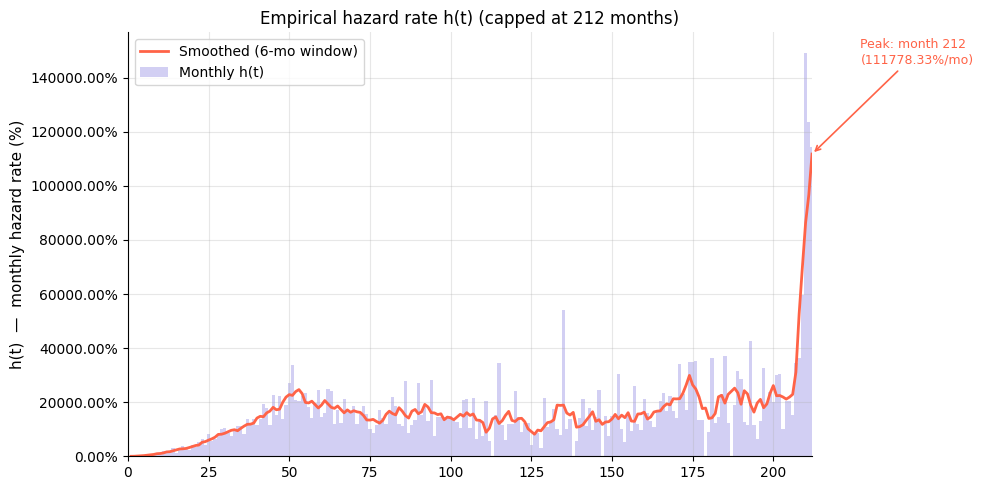

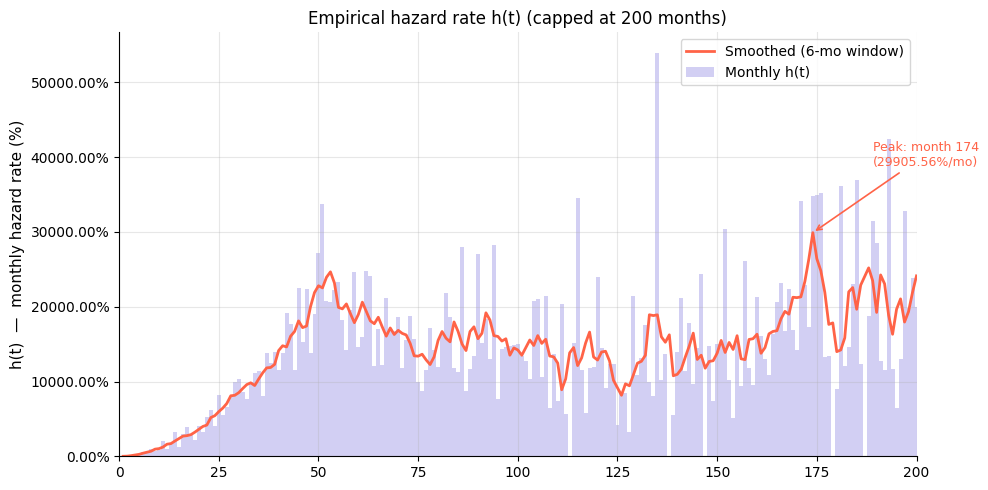

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Empirical hazard rate h(t) (capped at 200 months)'}, ylabel='h(t)  —  monthly hazard rate (%)'>,
          t  n_at_risk  n_events  hazard_raw  hazard_smoothed
 0      1.0          8       0.0    0.000000         0.000000
 1      2.0          6       0.0    0.000000         0.166667
 2      3.0          4       0.0    0.000000         0.847619
 3      4.0          6       4.0    0.666667         1.706349
 4      5.0          7      25.0    3.571429         2.581349
 ..     ...        ...       ...         ...              ...
 194  196.0          3     392.0  130.666667       210.500000
 195  197.0          3     985.0  328.333333       179.533333
 196  198.0          1     198.0  198.000000       193.466667
 197  199.0          5    1194.0  238.800000       219.160000
 198  200.0          1     200.0  200.000000       241.283333
 
 [199 rows x 5 columns])

In [5]:
# Empirical mode (also called "Instantanious")
chh.plot_hazard(df["duration_months"], df["event_observed"], df["t"], df["event_this_month"], mode="empirical")
chh.plot_hazard(df["duration_months"], df["event_observed"], df["t"], df["event_this_month"], mode="empirical", horizon=200)

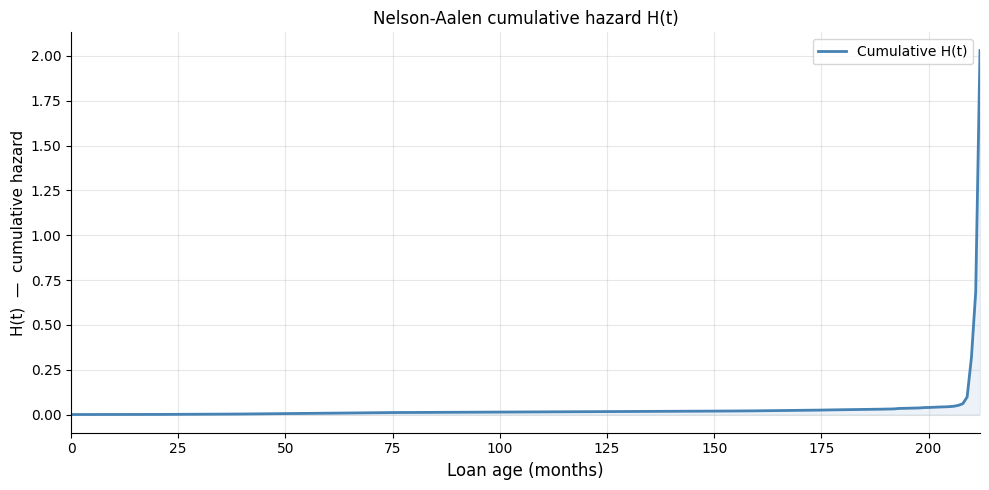

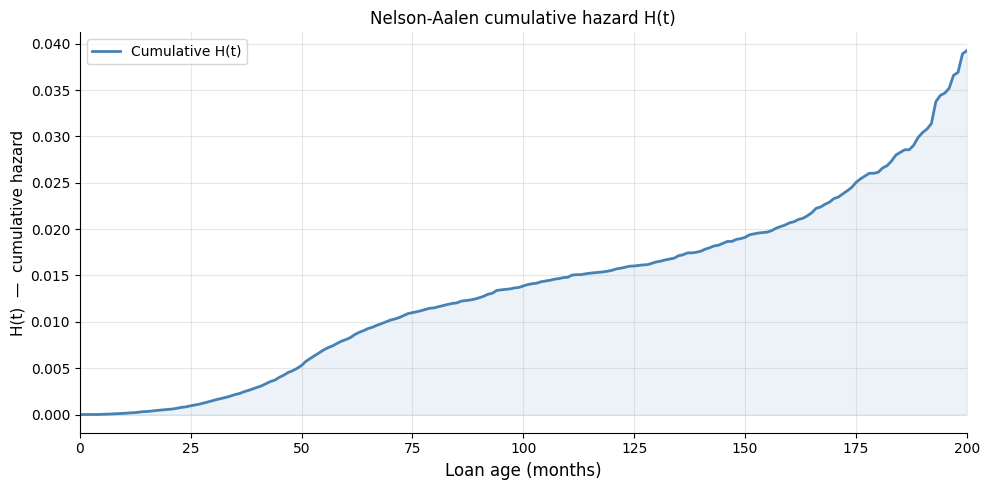

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Nelson-Aalen cumulative hazard H(t)'}, xlabel='Loan age (months)', ylabel='H(t)  —  cumulative hazard'>,
 <lifelines.NelsonAalenFitter:"NA_estimate", fitted with 319550 total observations, 317387 right-censored observations>)

In [6]:
# Cumulative mode
chh.plot_hazard(df["duration_months"], df["event_observed"], df["t"], df["event_this_month"], mode="cumulative")
chh.plot_hazard(df["duration_months"], df["event_observed"], df["t"], df["event_this_month"], mode="cumulative", horizon=200)

In [7]:
results = chh.summary(df["duration_months"], df["event_observed"], df["t"], df["event_this_month"])
results

{'loans_in_sample': 5000,
 'loan_months_in_panel': 319550,
 'peak_hazard_month': 53,
 'peak_hazard_rate': 1.762146485978174,
 'h_at_60mo': 0.18559877714298878,
 'h_at_120mo': 0.4639641131427972}